In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load 24h featured data
df = pd.read_parquet('../data/processed/delhi_aqi_24h_features.parquet')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

FEATURES = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'season',
    'AQI_lag_24h', 'AQI_lag_48h', 'AQI_lag_72h', 'AQI_lag_168h',
    'AQI_rolling_mean_24h', 'AQI_rolling_mean_48h',
    'AQI_rolling_std_24h', 'AQI_rolling_max_24h', 'AQI_rolling_min_24h',
    'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3'
]
TARGET = 'AQI_target_24h'

print("Data loaded:", df.shape)
print("Features:", len(FEATURES))
print("Target: AQI 24 hours ahead")
print("Date range:", df['Datetime'].min(), "to", df['Datetime'].max())

Data loaded: (47502, 29)
Features: 20
Target: AQI 24 hours ahead
Date range: 2015-01-08 16:00:00 to 2020-06-30 00:00:00


In [3]:
def rolling_backtest_24h(df, features, target, n_test_months=6):
    results = []
    
    df['month_period'] = df['Datetime'].dt.to_period('M')
    all_months = sorted(df['month_period'].unique())
    test_months = all_months[12:]
    
    print(f"Total months: {len(all_months)}")
    print(f"First test month: {test_months[0]}")
    print(f"Last test month: {test_months[-1]}")
    print(f"Running {len(test_months)} test windows...\n")
    
    for i, test_month in enumerate(test_months):
        train_mask = df['month_period'] < test_month
        test_mask  = df['month_period'] == test_month
        
        X_train = df.loc[train_mask, features]
        y_train = df.loc[train_mask, target]
        X_test  = df.loc[test_mask, features]
        y_test  = df.loc[test_mask, target]
        
        if len(X_test) == 0:
            continue
        
        models = {
            'LinearRegression': LinearRegression(),
            'RandomForest': RandomForestRegressor(
                n_estimators=100, random_state=42, n_jobs=-1
            ),
            'LightGBM': lgb.LGBMRegressor(
                n_estimators=300, learning_rate=0.05,
                num_leaves=63, random_state=42, verbose=-1
            )
        }
        
        window_results = {'month': str(test_month), 'n_test': len(X_test)}
        
        for name, model in models.items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            
            mae  = mean_absolute_error(y_test, preds)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            mape = np.mean(np.abs((y_test - preds) / y_test.clip(lower=1))) * 100
            
            window_results[f'{name}_MAE']  = round(mae, 2)
            window_results[f'{name}_RMSE'] = round(rmse, 2)
            window_results[f'{name}_MAPE'] = round(mape, 2)
        
        results.append(window_results)
        
        if (i + 1) % 6 == 0:
            print(f"  Completed {i+1}/{len(test_months)} windows...")
    
    return pd.DataFrame(results)

print("Starting 24h rolling backtest...")
results_df = rolling_backtest_24h(df, FEATURES, TARGET)
print("\nDone.")

Starting 24h rolling backtest...
Total months: 66
First test month: 2016-01
Last test month: 2020-06
Running 54 test windows...

  Completed 6/54 windows...
  Completed 12/54 windows...
  Completed 18/54 windows...
  Completed 24/54 windows...
  Completed 30/54 windows...
  Completed 36/54 windows...
  Completed 42/54 windows...
  Completed 48/54 windows...
  Completed 54/54 windows...

Done.


In [4]:
summary_cols = ['LinearRegression', 'RandomForest', 'LightGBM']
metrics = ['MAE', 'RMSE', 'MAPE']

print("=" * 55)
print("BACKTEST RESULTS — 24H FORECAST — 54 WINDOWS")
print("=" * 55)

for metric in metrics:
    print(f"\n{metric}:")
    for model in summary_cols:
        col = f'{model}_{metric}'
        mean_val = results_df[col].mean()
        std_val  = results_df[col].std()
        print(f"  {model:<20} {mean_val:.2f}  (±{std_val:.2f})")

print("\n" + "=" * 55)
print("BEST MODEL PER METRIC:")
print("=" * 55)
for metric in metrics:
    means = {m: results_df[f'{m}_{metric}'].mean() for m in summary_cols}
    best = min(means, key=means.get)
    print(f"  {metric}: {best} ({means[best]:.2f})")

# Also check LightGBM feature importance
print("\n" + "=" * 55)
print("LIGHTGBM FEATURE IMPORTANCE (final window)")
print("=" * 55)

# Train LightGBM on full data to get feature importance
lgb_final = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05,
    num_leaves=63, random_state=42, verbose=-1
)
lgb_final.fit(df[FEATURES], df[TARGET])

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': lgb_final.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

BACKTEST RESULTS — 24H FORECAST — 54 WINDOWS

MAE:
  LinearRegression     48.70  (±16.33)
  RandomForest         51.57  (±18.11)
  LightGBM             50.22  (±18.02)

RMSE:
  LinearRegression     60.62  (±19.50)
  RandomForest         65.19  (±21.45)
  LightGBM             63.43  (±21.25)

MAPE:
  LinearRegression     27.67  (±26.05)
  RandomForest         28.29  (±19.79)
  LightGBM             27.91  (±20.53)

BEST MODEL PER METRIC:
  MAE: LinearRegression (48.70)
  RMSE: LinearRegression (60.62)
  MAPE: LinearRegression (27.67)

LIGHTGBM FEATURE IMPORTANCE (final window)
             feature  importance
        AQI_lag_168h        1804
         AQI_lag_72h        1513
 AQI_rolling_min_24h        1344
               month        1292
 AQI_rolling_max_24h        1205
         AQI_lag_24h        1146
AQI_rolling_mean_48h        1111
                  CO        1033
         day_of_week        1004
 AQI_rolling_std_24h         899
                PM10         881
                  O3  

In [5]:
import requests

def fetch_delhi_weather():
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 28.6139,
        "longitude": 77.2090,
        "start_date": "2015-01-01",
        "end_date": "2020-07-01",
        "hourly": "temperature_2m,relativehumidity_2m,windspeed_10m,precipitation",
        "timezone": "Asia/Kolkata"
    }
    
    print("Fetching weather data from Open-Meteo...")
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print("Error:", response.status_code, response.text)
        return None
    
    data = response.json()
    
    weather_df = pd.DataFrame({
        'Datetime': pd.to_datetime(data['hourly']['time']),
        'temperature': data['hourly']['temperature_2m'],
        'humidity':    data['hourly']['relativehumidity_2m'],
        'windspeed':   data['hourly']['windspeed_10m'],
        'precipitation': data['hourly']['precipitation']
    })
    
    print("Weather data fetched:", weather_df.shape)
    print("Date range:", weather_df['Datetime'].min(), "to", weather_df['Datetime'].max())
    print("\nMissing values:")
    print(weather_df.isnull().sum())
    
    return weather_df

weather_df = fetch_delhi_weather()

Fetching weather data from Open-Meteo...
Weather data fetched: (48216, 5)
Date range: 2015-01-01 00:00:00 to 2020-07-01 23:00:00

Missing values:
Datetime         0
temperature      0
humidity         0
windspeed        0
precipitation    0
dtype: int64


In [6]:
# Reload clean AQI data
delhi_df = pd.read_csv('../data/processed/delhi_aqi_clean.csv')
delhi_df['Datetime'] = pd.to_datetime(delhi_df['Datetime'])
delhi_df = delhi_df.sort_values('Datetime').reset_index(drop=True)

# Merge weather on Datetime
delhi_df = delhi_df.merge(weather_df, on='Datetime', how='left')

print("Shape after merge:", delhi_df.shape)
print("Weather missing after merge:")
print(delhi_df[['temperature','humidity','windspeed','precipitation']].isnull().sum())

Shape after merge: (47694, 18)
Weather missing after merge:
temperature      0
humidity         0
windspeed        0
precipitation    0
dtype: int64


In [7]:
# ── TARGET ────────────────────────────────────────────────────────
delhi_df['AQI_target_24h'] = delhi_df['AQI'].shift(-24)

# ── TEMPORAL ──────────────────────────────────────────────────────
delhi_df['hour']        = delhi_df['Datetime'].dt.hour
delhi_df['day_of_week'] = delhi_df['Datetime'].dt.dayofweek
delhi_df['month']       = delhi_df['Datetime'].dt.month
delhi_df['is_weekend']  = (delhi_df['day_of_week'] >= 5).astype(int)
delhi_df['season']      = delhi_df['month'].map({
    12:0, 1:0, 2:0,
    3:1,  4:1, 5:1,
    6:2,  7:2, 8:2,
    9:3, 10:3, 11:3
})

# ── AQI LAG FEATURES ──────────────────────────────────────────────
for lag in [24, 48, 72, 168]:
    delhi_df[f'AQI_lag_{lag}h'] = delhi_df['AQI'].shift(lag)

# ── AQI ROLLING FEATURES ──────────────────────────────────────────
delhi_df['AQI_rolling_mean_24h'] = delhi_df['AQI'].shift(24).rolling(24, min_periods=1).mean()
delhi_df['AQI_rolling_mean_48h'] = delhi_df['AQI'].shift(24).rolling(48, min_periods=1).mean()
delhi_df['AQI_rolling_std_24h']  = delhi_df['AQI'].shift(24).rolling(24, min_periods=1).std()
delhi_df['AQI_rolling_max_24h']  = delhi_df['AQI'].shift(24).rolling(24, min_periods=1).max()
delhi_df['AQI_rolling_min_24h']  = delhi_df['AQI'].shift(24).rolling(24, min_periods=1).min()

# ── WEATHER LAG FEATURES ──────────────────────────────────────────
# Use weather from 24h ago — realistically available at prediction time
for col in ['temperature', 'humidity', 'windspeed', 'precipitation']:
    delhi_df[f'{col}_lag_24h'] = delhi_df[col].shift(24)
    delhi_df[f'{col}_rolling_mean_24h'] = delhi_df[col].shift(24).rolling(24, min_periods=1).mean()

# ── PREVIOUS YEAR SAME PERIOD ─────────────────────────────────────
delhi_df['AQI_lag_8760h'] = delhi_df['AQI'].shift(8760)  # ~1 year

# ── DROP NaN ROWS ─────────────────────────────────────────────────
delhi_df = delhi_df.dropna(subset=['AQI_lag_168h', 'AQI_target_24h', 'AQI_lag_8760h']).reset_index(drop=True)

# ── VERIFY ────────────────────────────────────────────────────────
print("Final shape:", delhi_df.shape)
print("\nMissing values:", delhi_df.isnull().sum().sum(), "total")

FEATURES_V2 = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'season',
    'AQI_lag_24h', 'AQI_lag_48h', 'AQI_lag_72h', 'AQI_lag_168h', 'AQI_lag_8760h',
    'AQI_rolling_mean_24h', 'AQI_rolling_mean_48h',
    'AQI_rolling_std_24h', 'AQI_rolling_max_24h', 'AQI_rolling_min_24h',
    'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3',
    'temperature_lag_24h', 'humidity_lag_24h', 
    'windspeed_lag_24h', 'precipitation_lag_24h',
    'temperature_rolling_mean_24h', 'humidity_rolling_mean_24h',
    'windspeed_rolling_mean_24h', 'precipitation_rolling_mean_24h'
]

print("Feature count:", len(FEATURES_V2))

Final shape: (38910, 42)

Missing values: 0 total
Feature count: 29


In [8]:
# Save
delhi_df.to_parquet('../data/processed/delhi_aqi_v2_features.parquet', index=False)
print("Saved to data/processed/delhi_aqi_v2_features.parquet")

Saved to data/processed/delhi_aqi_v2_features.parquet


In [9]:
# Load v2 features
df2 = pd.read_parquet('../data/processed/delhi_aqi_v2_features.parquet')
df2['Datetime'] = pd.to_datetime(df2['Datetime'])
df2 = df2.sort_values('Datetime').reset_index(drop=True)

FEATURES_V2 = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'season',
    'AQI_lag_24h', 'AQI_lag_48h', 'AQI_lag_72h', 'AQI_lag_168h', 'AQI_lag_8760h',
    'AQI_rolling_mean_24h', 'AQI_rolling_mean_48h',
    'AQI_rolling_std_24h', 'AQI_rolling_max_24h', 'AQI_rolling_min_24h',
    'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3',
    'temperature_lag_24h', 'humidity_lag_24h',
    'windspeed_lag_24h', 'precipitation_lag_24h',
    'temperature_rolling_mean_24h', 'humidity_rolling_mean_24h',
    'windspeed_rolling_mean_24h', 'precipitation_rolling_mean_24h'
]
TARGET = 'AQI_target_24h'

print("Data loaded:", df2.shape)
print("Features:", len(FEATURES_V2))
print("Date range:", df2['Datetime'].min(), "to", df2['Datetime'].max())

Data loaded: (38910, 42)
Features: 29
Date range: 2016-01-03 03:00:00 to 2020-06-30 00:00:00


In [10]:
print("Starting v2 backtest with weather features...")
results_v2 = rolling_backtest_24h(df2, FEATURES_V2, TARGET)
print("\nDone.")

Starting v2 backtest with weather features...
Total months: 54
First test month: 2017-01
Last test month: 2020-06
Running 42 test windows...

  Completed 6/42 windows...
  Completed 12/42 windows...
  Completed 18/42 windows...
  Completed 24/42 windows...
  Completed 30/42 windows...
  Completed 36/42 windows...
  Completed 42/42 windows...

Done.


In [11]:
summary_cols = ['LinearRegression', 'RandomForest', 'LightGBM']
metrics = ['MAE', 'RMSE', 'MAPE']

print("=" * 60)
print("V2 RESULTS (with weather) — 24H FORECAST")
print("=" * 60)

for metric in metrics:
    print(f"\n{metric}:")
    for model in summary_cols:
        col = f'{model}_{metric}'
        mean_val = results_v2[col].mean()
        std_val  = results_v2[col].std()
        print(f"  {model:<20} {mean_val:.2f}  (±{std_val:.2f})")

print("\n" + "=" * 60)
print("IMPROVEMENT OVER V1 (lower is better):")
print("=" * 60)
for metric in metrics:
    for model in summary_cols:
        col = f'{model}_{metric}'
        v1 = results_df[col].mean()
        v2 = results_v2[col].mean()
        improvement = ((v1 - v2) / v1) * 100
        direction = "better" if improvement > 0 else "worse"
        print(f"  {model:<20} {metric}: {improvement:+.1f}% {direction}")

V2 RESULTS (with weather) — 24H FORECAST

MAE:
  LinearRegression     45.22  (±18.10)
  RandomForest         50.81  (±23.00)
  LightGBM             48.19  (±21.02)

RMSE:
  LinearRegression     57.13  (±21.64)
  RandomForest         64.59  (±27.33)
  LightGBM             61.35  (±25.61)

MAPE:
  LinearRegression     27.33  (±26.68)
  RandomForest         29.97  (±24.35)
  LightGBM             27.64  (±20.50)

IMPROVEMENT OVER V1 (lower is better):
  LinearRegression     MAE: +7.1% better
  RandomForest         MAE: +1.5% better
  LightGBM             MAE: +4.0% better
  LinearRegression     RMSE: +5.8% better
  RandomForest         RMSE: +0.9% better
  LightGBM             RMSE: +3.3% better
  LinearRegression     MAPE: +1.2% better
  RandomForest         MAPE: -5.9% worse
  LightGBM             MAPE: +1.0% better


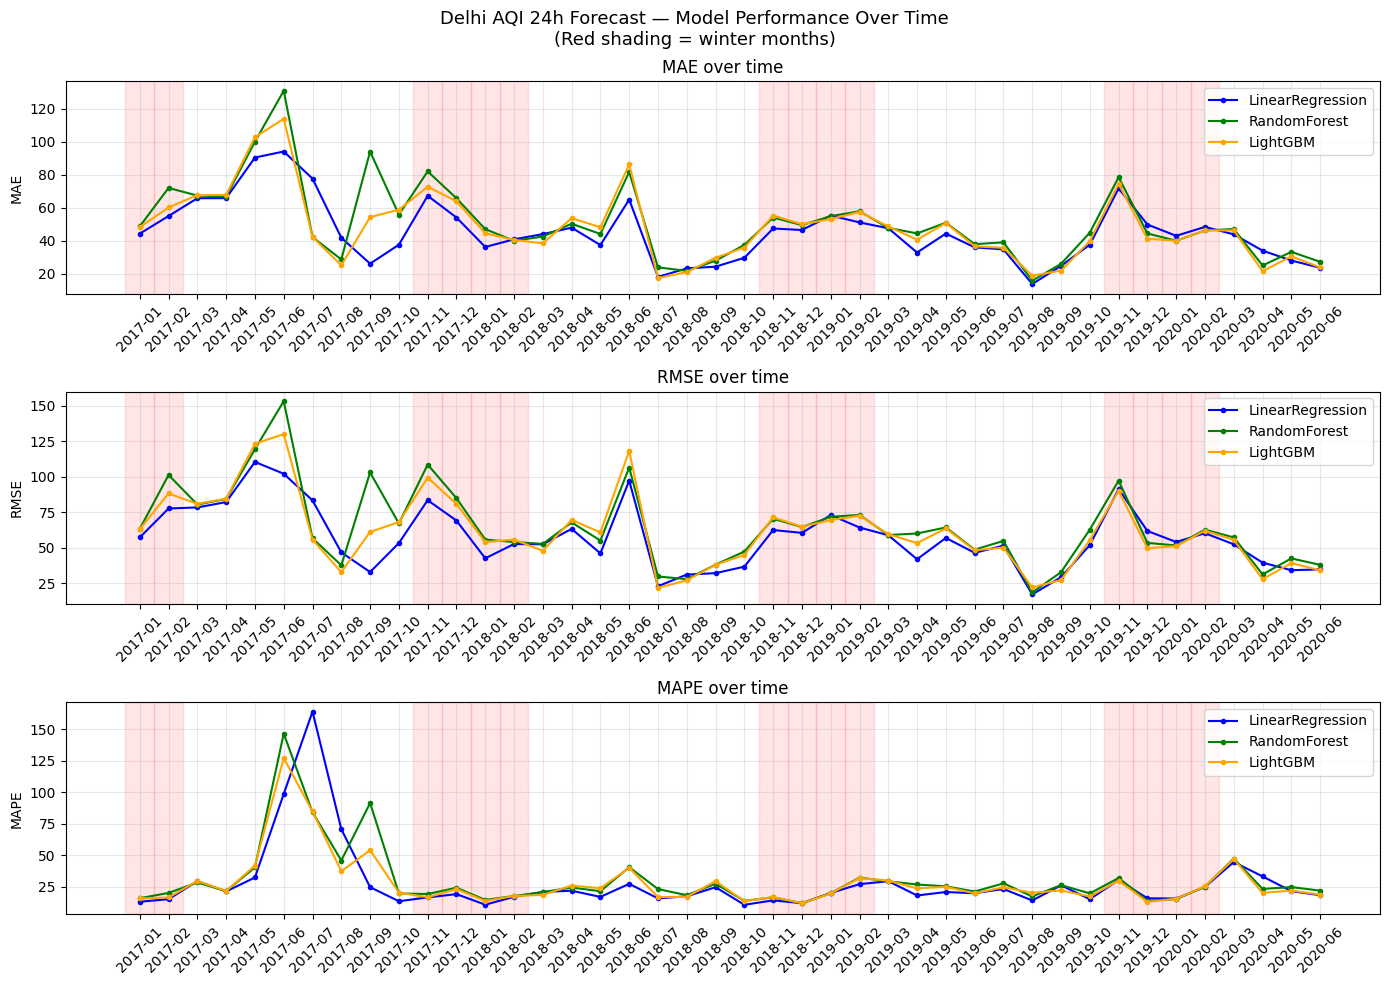

Plot saved to data/processed/model_comparison.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

metrics = ['MAE', 'RMSE', 'MAPE']
colors  = {'LinearRegression': 'blue', 
           'RandomForest': 'green', 
           'LightGBM': 'orange'}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    for model in ['LinearRegression', 'RandomForest', 'LightGBM']:
        ax.plot(results_v2['month'], 
                results_v2[f'{model}_{metric}'],
                label=model, 
                color=colors[model],
                marker='o', 
                markersize=3)
    
    ax.set_title(f'{metric} over time', fontsize=12)
    ax.set_ylabel(metric)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Highlight winter months (Nov-Feb) in light red
    for i, month in enumerate(results_v2['month']):
        m = int(month.split('-')[1])
        if m in [11, 12, 1, 2]:
            ax.axvspan(i-0.5, i+0.5, alpha=0.1, color='red')

plt.suptitle('Delhi AQI 24h Forecast — Model Performance Over Time\n(Red shading = winter months)', 
             fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/model_comparison.png")

In [13]:
# Split results: 2017 vs 2018 onwards
results_v2['year'] = results_v2['month'].str[:4]

print("=" * 55)
print("PERFORMANCE BY YEAR — LightGBM")
print("=" * 55)
for year in ['2017', '2018', '2019', '2020']:
    subset = results_v2[results_v2['year'] == year]
    if len(subset) == 0:
        continue
    mae  = subset['LightGBM_MAE'].mean()
    mape = subset['LightGBM_MAPE'].mean()
    print(f"  {year}:  MAE={mae:.1f}  MAPE={mape:.1f}%  ({len(subset)} months)")

print("\n" + "=" * 55)
print("PERFORMANCE 2018 ONWARDS — ALL MODELS")
print("=" * 55)
subset_2018 = results_v2[results_v2['year'] >= '2018']
for model in ['LinearRegression', 'RandomForest', 'LightGBM']:
    mae  = subset_2018[f'{model}_MAE'].mean()
    mape = subset_2018[f'{model}_MAPE'].mean()
    print(f"  {model:<20} MAE={mae:.1f}  MAPE={mape:.1f}%")

PERFORMANCE BY YEAR — LightGBM
  2017:  MAE=64.7  MAPE=40.7%  (12 months)
  2018:  MAE=43.4  MAPE=20.5%  (12 months)
  2019:  MAE=43.2  MAPE=23.1%  (12 months)
  2020:  MAE=34.7  MAPE=24.8%  (6 months)

PERFORMANCE 2018 ONWARDS — ALL MODELS
  LinearRegression     MAE=39.3  MAPE=21.0%
  RandomForest         MAE=42.7  MAPE=23.4%
  LightGBM             MAE=41.6  MAPE=22.4%


In [14]:
# Proper LightGBM tuning on 2018+ data
# Using last 2 years as validation for tuning

train_mask = (df2['Datetime'] < '2019-01-01')
val_mask   = (df2['Datetime'] >= '2019-01-01')

X_train = df2.loc[train_mask, FEATURES_V2]
y_train = df2.loc[train_mask, TARGET]
X_val   = df2.loc[val_mask, FEATURES_V2]
y_val   = df2.loc[val_mask, TARGET]

param_grid = [
    {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31,  'min_child_samples': 20},
    {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63,  'min_child_samples': 20},
    {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 20},
    {'n_estimators': 500, 'learning_rate': 0.01, 'num_leaves': 63,  'min_child_samples': 50},
    {'n_estimators': 800, 'learning_rate': 0.02, 'num_leaves': 63,  'min_child_samples': 30},
]

print("Tuning LightGBM — testing 5 parameter sets...\n")
best_mae  = float('inf')
best_params = None

for i, params in enumerate(param_grid):
    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    mae  = mean_absolute_error(y_val, preds)
    mape = np.mean(np.abs((y_val - preds) / y_val.clip(lower=1))) * 100
    print(f"  Params {i+1}: MAE={mae:.2f}  MAPE={mape:.2f}%  {params}")
    
    if mae < best_mae:
        best_mae = mae
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best MAE: {best_mae:.2f}")

# Compare against Linear Regression on same split
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_mae  = mean_absolute_error(y_val, lr_preds)
lr_mape = np.mean(np.abs((y_val - lr_preds) / y_val.clip(lower=1))) * 100
print(f"\nLinear Regression on same split: MAE={lr_mae:.2f}  MAPE={lr_mape:.2f}%")
print(f"\nWinner: {'LightGBM' if best_mae < lr_mae else 'LinearRegression'}")

Tuning LightGBM — testing 5 parameter sets...

  Params 1: MAE=46.29  MAPE=28.39%  {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20}
  Params 2: MAE=46.78  MAPE=28.80%  {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 20}
  Params 3: MAE=49.95  MAPE=31.36%  {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 20}
  Params 4: MAE=44.28  MAPE=27.17%  {'n_estimators': 500, 'learning_rate': 0.01, 'num_leaves': 63, 'min_child_samples': 50}
  Params 5: MAE=45.57  MAPE=27.88%  {'n_estimators': 800, 'learning_rate': 0.02, 'num_leaves': 63, 'min_child_samples': 30}

Best params: {'n_estimators': 500, 'learning_rate': 0.01, 'num_leaves': 63, 'min_child_samples': 50}
Best MAE: 44.28

Linear Regression on same split: MAE=41.03  MAPE=24.32%

Winner: LinearRegression


In [15]:
# Train final Linear Regression on ALL available data
X_final = df2[FEATURES_V2]
y_final = df2[TARGET]

final_model = LinearRegression()
final_model.fit(X_final, y_final)

# Save model and feature list together
model_artifact = {
    'model': final_model,
    'features': FEATURES_V2,
    'target': TARGET,
    'trained_on': str(df2['Datetime'].max().date()),
    'backtest_MAE_2018plus': 39.3,
    'backtest_MAPE_2018plus': 21.0,
    'n_training_rows': len(X_final)
}

joblib.dump(model_artifact, '../models/delhi_aqi_model.pkl')
print("Model saved to models/delhi_aqi_model.pkl")

# Verify it loads correctly
loaded = joblib.load('../models/delhi_aqi_model.pkl')
test_pred = loaded['model'].predict(X_final.iloc[:1])
print(f"Verification prediction: {test_pred[0]:.1f}")
print(f"Features saved: {len(loaded['features'])}")
print(f"Trained on data up to: {loaded['trained_on']}")
print(f"Backtest MAE (2018+): {loaded['backtest_MAE_2018plus']}")
print(f"Backtest MAPE (2018+): {loaded['backtest_MAPE_2018plus']}%")

Model saved to models/delhi_aqi_model.pkl
Verification prediction: 465.5
Features saved: 29
Trained on data up to: 2020-06-30
Backtest MAE (2018+): 39.3
Backtest MAPE (2018+): 21.0%
